In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import tifffile


In [2]:
def plot_all_functions(experiment):
    base_path =f'/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/{experiment}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted'
    path_to_fluor_stack_dir=f'{base_path}/fluor_kymos'
    path_to_phase_stack_dir=f'{base_path}'
    path_to_labels_stack_dir =f'{base_path}/mask_kymos'
    phase_list = os.listdir(path_to_phase_stack_dir)
    mask_list =os.listdir(path_to_labels_stack_dir)
    fluor_list =os.listdir(path_to_fluor_stack_dir)
    tab20_cmap = plt.get_cmap("tab20")


    for file_name in mask_list:
        if file_name in phase_list and file_name in fluor_list:
            base_name = file_name.replace('.tif', '')
            path_to_mask_stack = f'{path_to_labels_stack_dir}/{file_name}'
            path_to_phase_stack = f'{path_to_phase_stack_dir}/{file_name}'
            path_to_fluor_stack =f'{path_to_fluor_stack_dir}/{file_name}'
            
            phase_kymograph=tifffile.imread(path_to_phase_stack)
            fluor_kymograph=tifffile.imread(path_to_fluor_stack)
            mask_kymograph=tifffile.imread(path_to_mask_stack)

            colored_mask = np.zeros((*mask_kymograph.shape, 4), dtype=np.float32)  
            unique_labels = np.unique(mask_kymograph)
            for label in unique_labels:
                if label > 0: 
                    mask_indices = (mask_kymograph == label)
                    colored_mask[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
                    colored_mask[mask_indices, 3] = 1.0  

            plt.figure(figsize=(12, 8))

            plt.subplot(1, 3, 1)
            plt.imshow(phase_kymograph, cmap='gray')
            plt.title(f'Phase {base_name}')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(phase_kymograph, cmap='gray')  
            plt.imshow(colored_mask, alpha=0.5)  
            plt.title(f'Mask {base_name}')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(fluor_kymograph, cmap='gray')  
            plt.title(f'Fluor {base_name}')
            plt.axis('off')
            
            # Show the plot
            plt.show()        

### here is where you can type in the experiment name and it should plot all the available kymographs we have for the experiment!
### you must be connected to oak already to access the images

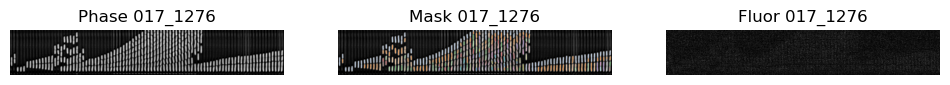

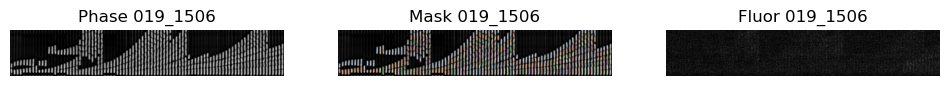

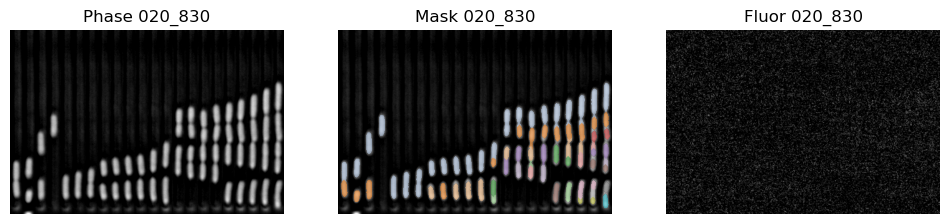

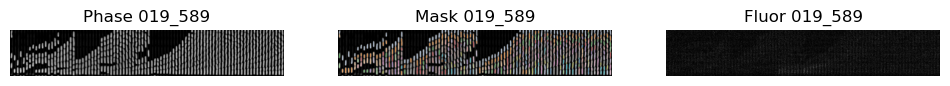

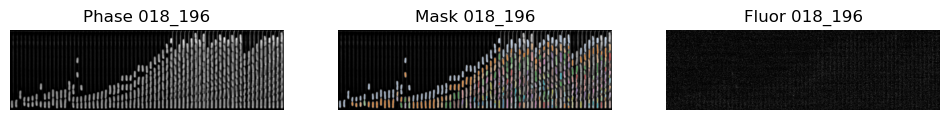

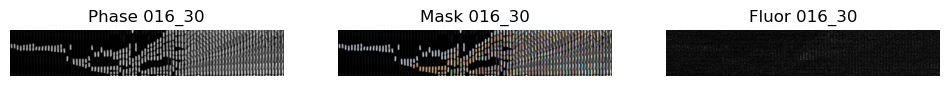

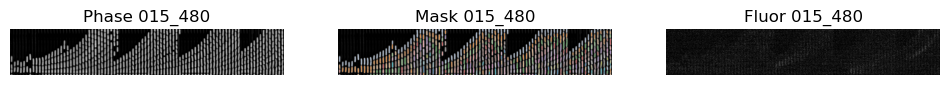

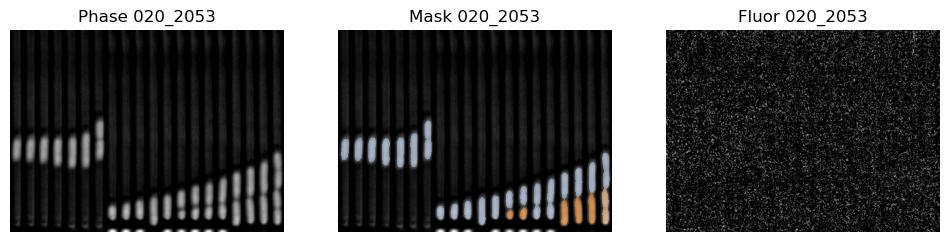

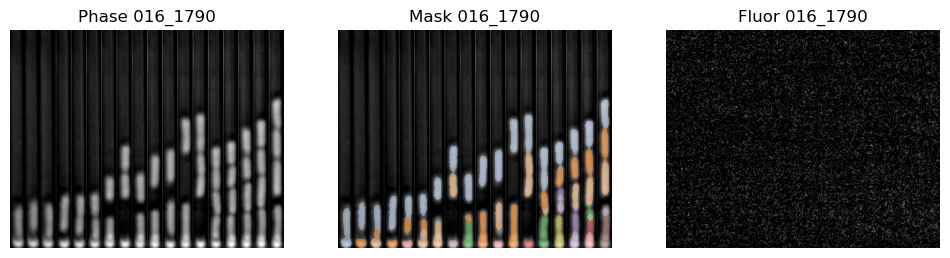

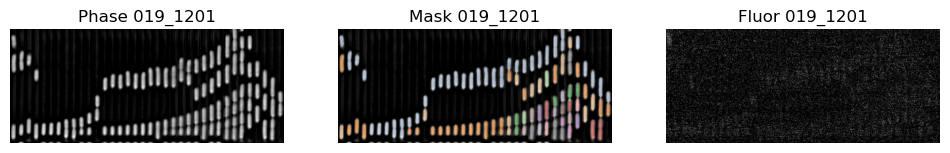

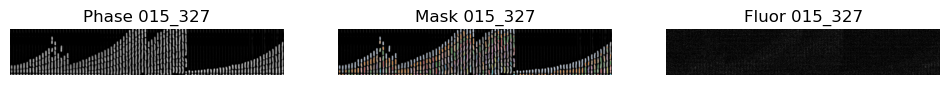

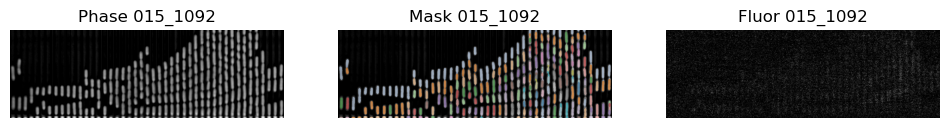

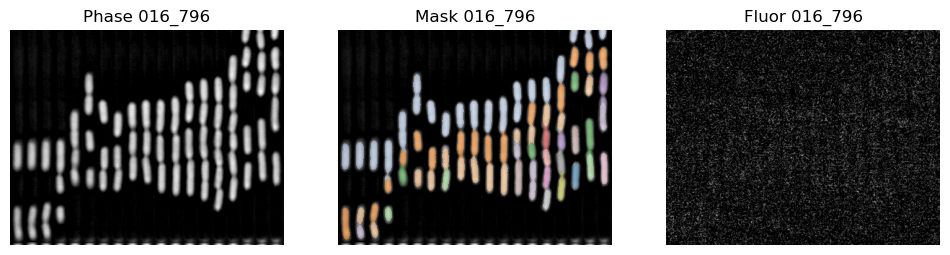

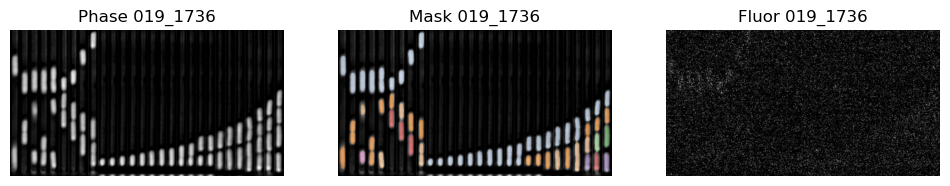

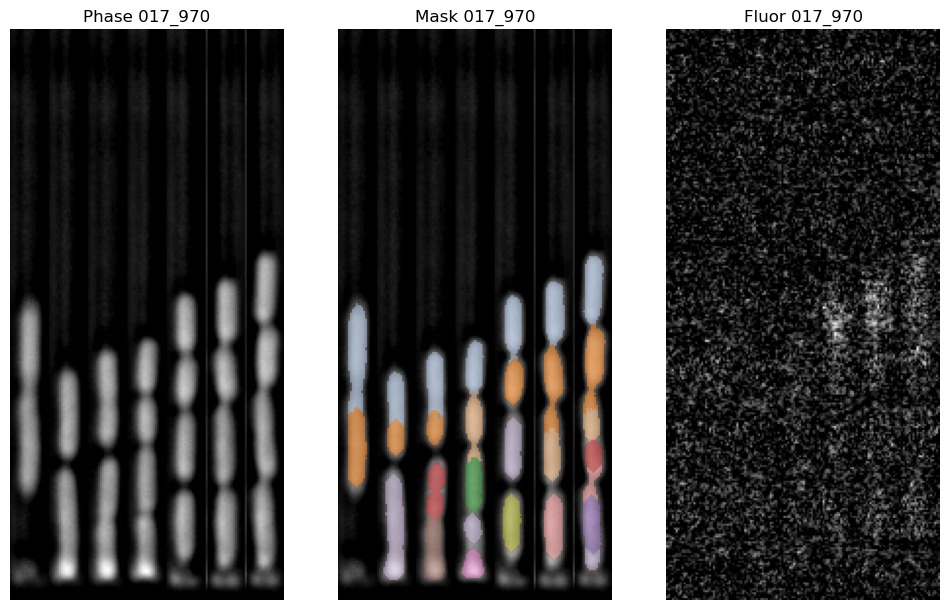

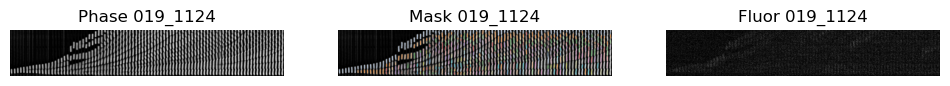

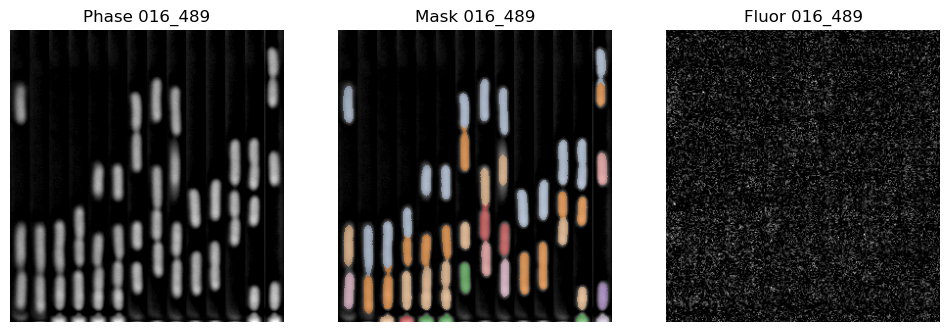

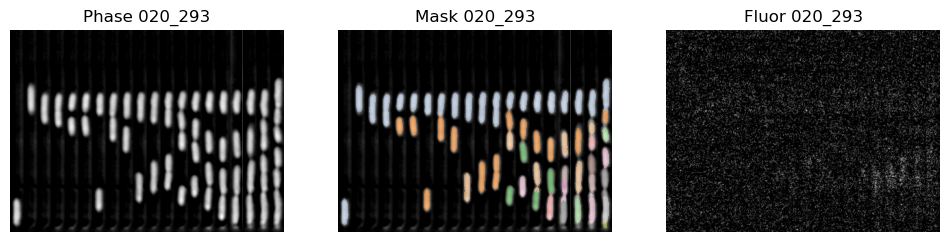

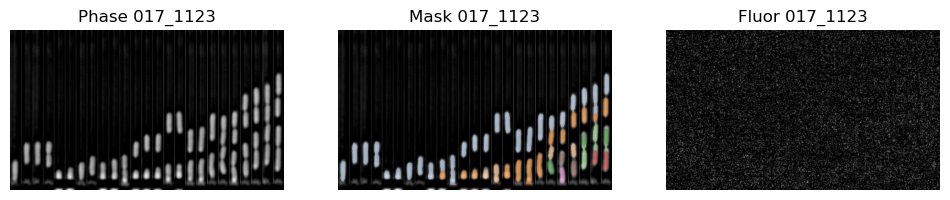

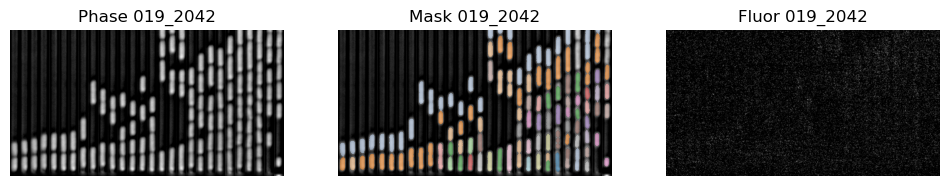

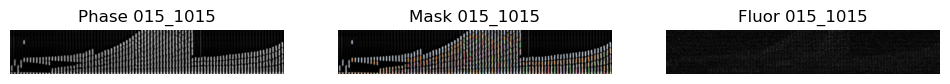

In [4]:

experiment ='DUMM_CL008_giTG061_081225'
plot_all_functions(experiment)